In [1]:
import numpy as np
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings("ignore")

In [2]:
data = fetch_california_housing()
X, y = data.data, data.target

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [4]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [5]:
y_pred = model.predict(X_test)

# Regressziós metrikák

## MAE (Mean Absolute Error)
- Átlagosan mennyit téved a modell
- Példa: ha 10, akkor kb. 10 egységet hibázik

## MSE (Mean Squared Error)
- A hibákat négyzetre emeli, ezért a nagy hibákat nagyon bünteti
- Inkább számolásra használják, nem közvetlen értelmezésre

## RMSE (Root Mean Squared Error)
- Ugyanaz a hiba, mint az MSE, csak vissza van hozva az eredeti skálára
- Példa: tipikus hiba nagysága

## R² (R-squared)
- Megmutatja, mennyire jól írja le a modell az adatokat
- 1 = tökéletes, 0 = rossz, 0 alatt = nagyon rossz

In [6]:
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2:", r2_score(y_test, y_pred))

MAE: 0.5332001304956989
MSE: 0.5558915986952425
RMSE: 0.7455813830127751
R2: 0.5757877060324521


In [7]:
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)

In [8]:
data = load_breast_cancer()
X = data.data
y = data.target

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
model = LogisticRegression()
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [11]:
y_pred = model.predict(X_test)

# Osztályozási metrikák

## Accuracy (Pontosság)
- Összesen hány találat jó
- Gyors, de imbalanced adatoknál félrevezető lehet

## Balanced Accuracy
- Osztályonként kiegyensúlyozott pontosság
- Akkor jó, ha az osztályok nem egyenlő arányúak

## Precision (Precizitás)
- A pozitívnak jelölt esetekből mennyi volt tényleg pozitív
- „Ha azt mondom, igen, mennyire igaz?”

## Recall (Emlékezés)
- A valódi pozitív esetekből mennyit talált meg
- „A fontos esetekből mennyit nem hagytam ki?”

## F1-score
- Precision és recall egyensúlya
- Akkor hasznos, ha mindkettő fontos

## Classification Report
- Precision, recall, F1-score osztályonként
- Részletes kép minden kategóriáról

## Confusion Matrix
- Valós vs predikált értékek táblázata
- Megmutatja pontosan, melyik osztályokat keveri a modell

In [12]:
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    log_loss,
    precision_score,
    recall_score,
    roc_auc_score,
)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average="weighted"))
print("Recall:", recall_score(y_test, y_pred, average="weighted"))
print("F1-score:", f1_score(y_test, y_pred, average="weighted"))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9473684210526315
Balanced Accuracy: 0.9348182115951523
Precision: 0.9488079172289698
Recall: 0.9473684210526315
F1-score: 0.9468057045386604

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.88      0.93        43
           1       0.93      0.99      0.96        71

    accuracy                           0.95       114
   macro avg       0.95      0.93      0.94       114
weighted avg       0.95      0.95      0.95       114



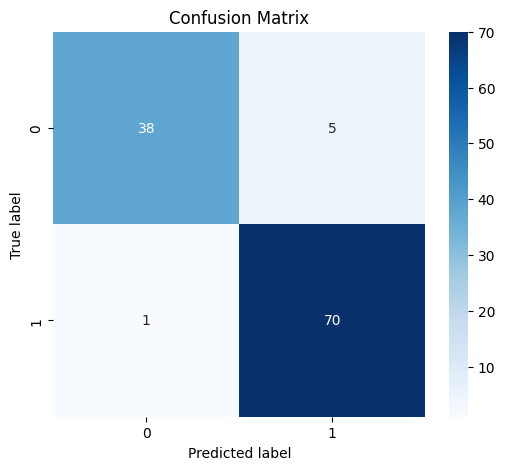

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.show()

In [14]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(model, X, y, cv=5)

print("Pontszámok foldonként:", scores)
print("Átlagos pontszám:", scores.mean())

Pontszámok foldonként: [0.92982456 0.93859649 0.95614035 0.95614035 0.94690265]
Átlagos pontszám: 0.9455208818506444
